In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the classic Titanic dataset (passenger info + survival outcome)
df = sns.load_dataset("titanic")
df.shape

Matplotlib is building the font cache; this may take a moment.


(891, 15)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
# Drop columns that are redundant or too sparse to be useful
# - deck: ~77% missing, not usable
# - embark_town: duplicate of 'embarked'
# - alive: duplicate of 'survived' (just text instead of 0/1)
# - class: duplicate of 'pclass'
# - who, adult_male: derived from sex/age, redundant for our purposes
df_clean = df.drop(columns=["deck", "embark_town", "alive", "class", "who", "adult_male"])

# Fill missing 'age' with the median age (robust to outliers, unlike the mean)
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Fill missing 'embarked' with the most common value (mode)
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])

# Confirm no missing values remain
df_clean.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

In [4]:
# Convert 'sex' to numeric: female=0, male=1
df_clean["sex"] = df_clean["sex"].map({"female": 0, "male": 1})

# One-hot encode 'embarked' (3 categories: C, Q, S) into separate 0/1 columns
df_clean = pd.get_dummies(df_clean, columns=["embarked"], drop_first=True)

df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,False,False,False
2,1,3,0,26.0,0,0,7.9250,True,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,True,False,True


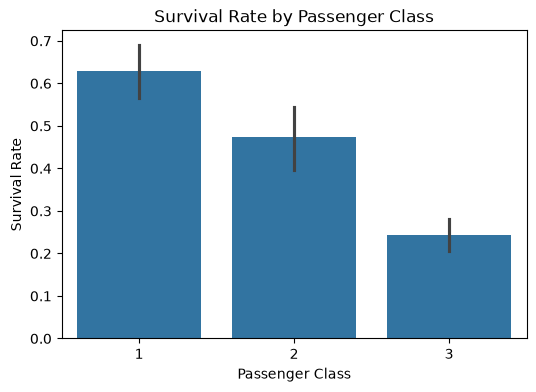

In [5]:
plt.figure(figsize=(6,4))
sns.barplot(x="pclass", y="survived", data=df_clean)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

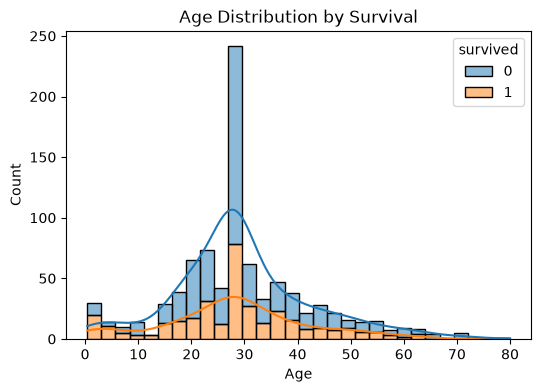

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(data=df_clean, x="age", hue="survived", bins=30, kde=True, multiple="stack")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["survived"])
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((712, 9), (179, 9))

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    results[name] = accuracy

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Test Accuracy"])
results_df = results_df.sort_values("Test Accuracy", ascending=False)
results_df

,Model,Test Accuracy
3,Random Forest,0.810056
0,Logistic Regression,0.798883
2,Decision Tree,0.793296
4,Naive Bayes,0.776536
1,KNN,0.703911


In [9]:
from sklearn.cluster import KMeans

# Use a subset of numeric features for clustering
cluster_features = X[["pclass", "age", "fare", "sibsp", "parch"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_features)

df_clean["cluster"] = clusters
df_clean[["pclass", "age", "fare", "cluster"]].groupby("cluster").mean()

,pclass,age,fare
cluster,,,
0,2.551440,28.278807,15.453954
1,1.000000,30.850000,279.308545
2,1.246479,34.710704,83.393280


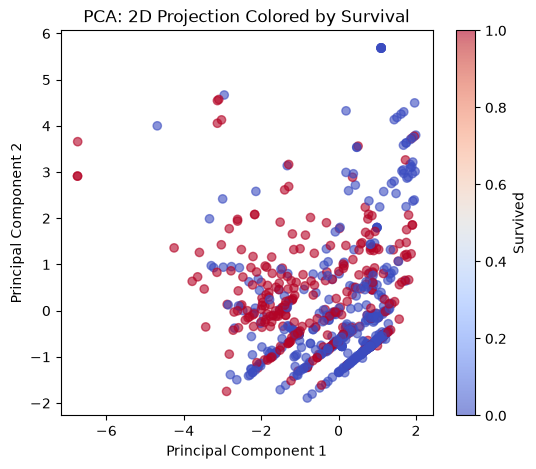

Variance explained by each component: [0.33960812 0.32520788]


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale features first - PCA is sensitive to feature scale, just like KNN
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

plt.figure(figsize=(6,5))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_clean["survived"], cmap="coolwarm", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 2D Projection Colored by Survival")
plt.colorbar(scatter, label="Survived")
plt.show()

print("Variance explained by each component:", pca.explained_variance_ratio_)

## Other clustering & dimensionality reduction methods (notes only, not implemented)

- **Hierarchical Clustering**: builds a tree of clusters by repeatedly merging the closest pairs of points/clusters. Useful when you want to see groupings at multiple levels of granularity (a dendrogram), not just one fixed k.
- **DBSCAN**: groups points based on density rather than distance to a center — finds clusters of any shape and automatically identifies outliers/noise points that don't belong to any cluster. Doesn't require choosing k upfront.
- **Gaussian Mixture Models (GMM)**: like K-Means but "soft" — instead of assigning each point to exactly one cluster, it gives a probability of belonging to each cluster, assuming clusters are shaped like overlapping bell curves.
- **t-SNE**: similar goal to PCA (compress to 2D for visualization), but better at preserving local neighborhood structure for highly non-linear data — at the cost of being slower and not preserving global distances as meaningfully as PCA.
- **Autoencoders**: a neural network trained to compress data down then reconstruct it back to the original — the compressed middle layer acts as a learned, non-linear alternative to PCA.